Project Overview

The objective of this project is to build machine learning models that classify breast tumors as malignant or benign using diagnostic measurements from the Breast Cancer Wisconsin dataset.

Import Required Libraries

In [275]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
print(os.getcwd())


c:\Users\ahmad\Downloads\Breast-Cancer-ML\notebooks


Initial Data Exploration


In [276]:
import pandas as pd

df = pd.read_csv("../data/breast-cancer.csv")
df.head()





,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


Data Preparation 

In [277]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
842302,568.0,3.042382e+07,1.251246e+08,8670.000000,869222.500000,906157.000000,8.825022e+06,9.113205e+08
17.99,568.0,1.412049e+01,3.523416e+00,6.981000,11.697500,13.355000,1.578000e+01,2.811000e+01
10.38,568.0,1.930533e+01,4.288506e+00,9.710000,16.177500,18.855000,2.180250e+01,3.928000e+01
122.8,568.0,9.191475e+01,2.428585e+01,43.790000,75.135000,86.210000,1.038750e+02,1.885000e+02
1001,568.0,6.542798e+02,3.519238e+02,143.500000,420.175000,548.750000,7.826250e+02,2.501000e+03
0.1184,568.0,9.632148e-02,1.404601e-02,0.052630,0.086290,0.095865,1.053000e-01,1.634000e-01
0.2776,568.0,1.040360e-01,5.235523e-02,0.019380,0.064815,0.092525,1.304000e-01,3.454000e-01
0.3001,568.0,8.842731e-02,7.929422e-02,0.000000,0.029540,0.061400,1.296500e-01,4.268000e-01
0.1471,568.0,4.874629e-02,3.861717e-02,0.000000,0.020310,0.033455,7.373000e-02,2.012000e-01
0.2419,568.0,1.810549e-01,2.731942e-02,0.106000,0.161900,0.179200,1.956250e-01,3.040000e-01


In [278]:
print(df.columns)
columns = [
'id','diagnosis',
'radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean',
'compactness_mean','concavity_mean','concave_points_mean','symmetry_mean','fractal_dimension_mean',
'radius_se','texture_se','perimeter_se','area_se','smoothness_se',
'compactness_se','concavity_se','concave_points_se','symmetry_se','fractal_dimension_se',
'radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst',
'compactness_worst','concavity_worst','concave_points_worst','symmetry_worst','fractal_dimension_worst'
]

df.columns = columns


Index(['842302', 'M', '17.99', '10.38', '122.8', '1001', '0.1184', '0.2776',
       '0.3001', '0.1471', '0.2419', '0.07871', '1.095', '0.9053', '8.589',
       '153.4', '0.006399', '0.04904', '0.05373', '0.01587', '0.03003',
       '0.006193', '25.38', '17.33', '184.6', '2019', '0.1622', '0.6656',
       '0.7119', '0.2654', '0.4601', '0.1189'],
      dtype='object')


In [279]:
df.groupby('diagnosis').mean()


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,2.654382e+07,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
M,3.698855e+07,17.460332,21.658104,115.330142,978.269194,0.102825,0.144560,0.160114,0.087710,0.192677,...,21.114692,29.375024,141.165450,1419.458294,0.144763,0.373446,0.449367,0.181843,0.322820,0.091400


In [280]:
df['diagnosis'].value_counts()



diagnosis
B    357
M    211
Name: count, dtype: int64

Exploratory Data Analysis

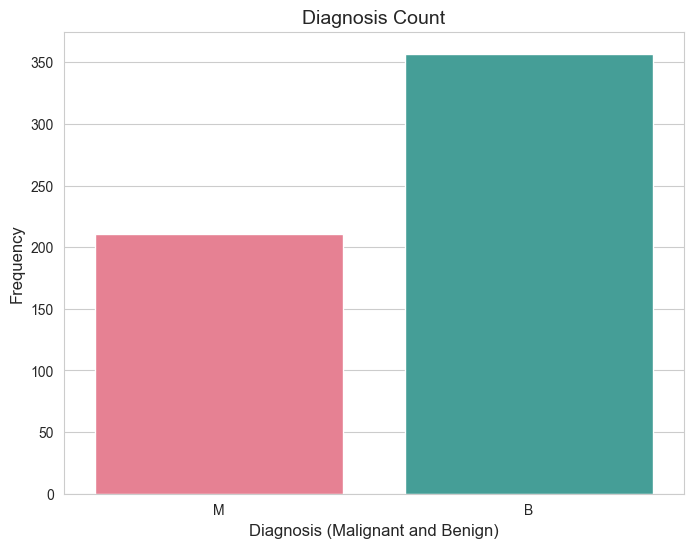

In [281]:

# Assuming 'df' is your DataFrame and 'diagnosis' is the column
plt.figure(figsize=(8, 6))  # Optional: Adjust the figure size
sns.countplot(x='diagnosis', data=df, palette='husl')

# Customizing the axis labels
plt.xlabel('Diagnosis (Malignant and Benign)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Adding a title (optional)
plt.title('Diagnosis Count', fontsize=14)

plt.show()


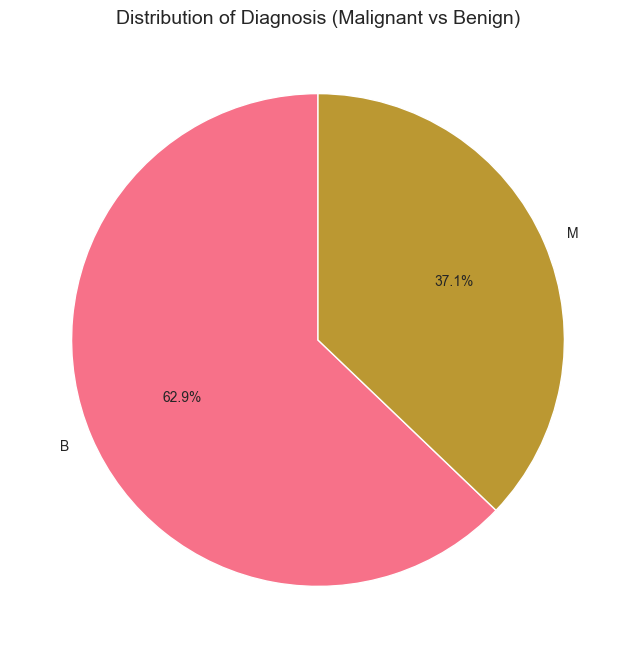

In [282]:
percentages = df['diagnosis'].value_counts(normalize=True) * 100

# Labels for the pie chart
labels = percentages.index

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(percentages, labels=labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('husl'))

# Adding a title
plt.title('Distribution of Diagnosis (Malignant vs Benign)', fontsize=14)

plt.show()


['M' 'B']
Malignant DataFrame shape: (211, 32)
Benign DataFrame shape: (357, 32)


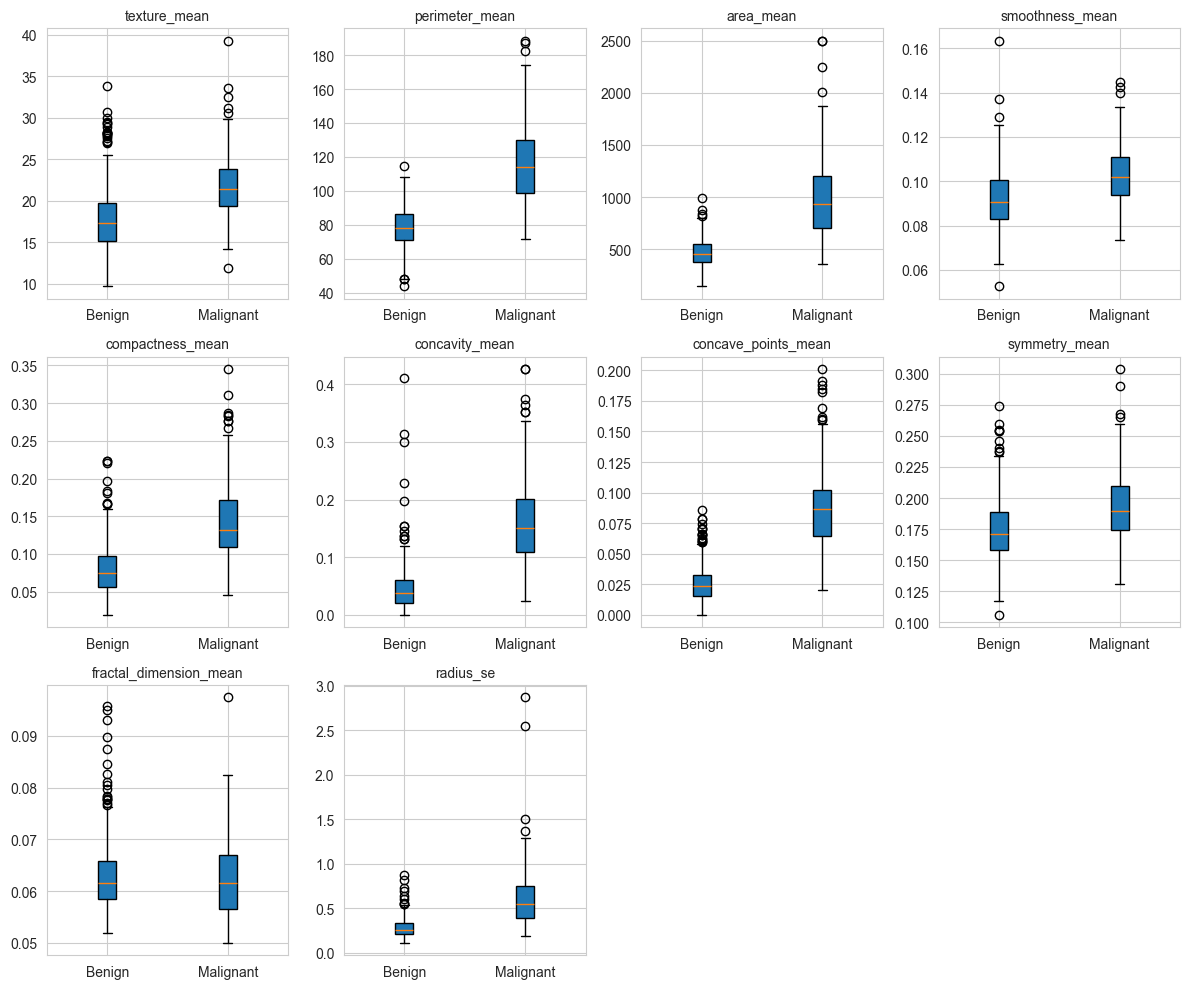

In [283]:
print(df['diagnosis'].unique())  # Check unique values in the 'diagnosis' column
# Filter DataFrames based on the 'diagnosis' column
df_malignant = df[df['diagnosis'] == 'M']  # Malignant
df_benign = df[df['diagnosis'] == 'B']    # Benign

# Check the resulting DataFrames
print("Malignant DataFrame shape:", df_malignant.shape)
print("Benign DataFrame shape:", df_benign.shape)
features = list(df.select_dtypes(include=['float64', 'int']).columns[2:12])  # Adjust as necessary

# Create a figure
fig = plt.figure(figsize=(12, 10))

# Loop through features and create subplots
for i, feature in enumerate(features):
    i += 1  # Adjust index for subplotting (1-based indexing)
    
    # Create subplot
    ax = fig.add_subplot(3, 4, i)
    
    # Create boxplot comparing malignant and benign
    ax.boxplot([df_benign[feature].dropna(), df_malignant[feature].dropna()], 
               labels=['Benign', 'Malignant'], patch_artist=True)
    
    # Set title for each subplot
    ax.set_title(feature, fontsize=10)

# Apply style and layout adjustments
sns.set_style("whitegrid")
plt.tight_layout()

# Show plot
plt.show()






In [284]:
import pandas as pd
import numpy as np

# Outlier handling function
def handle_outliers(df, columns, method="cap"):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        if method == "remove":
            df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
        elif method == "cap":
            df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
            df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df


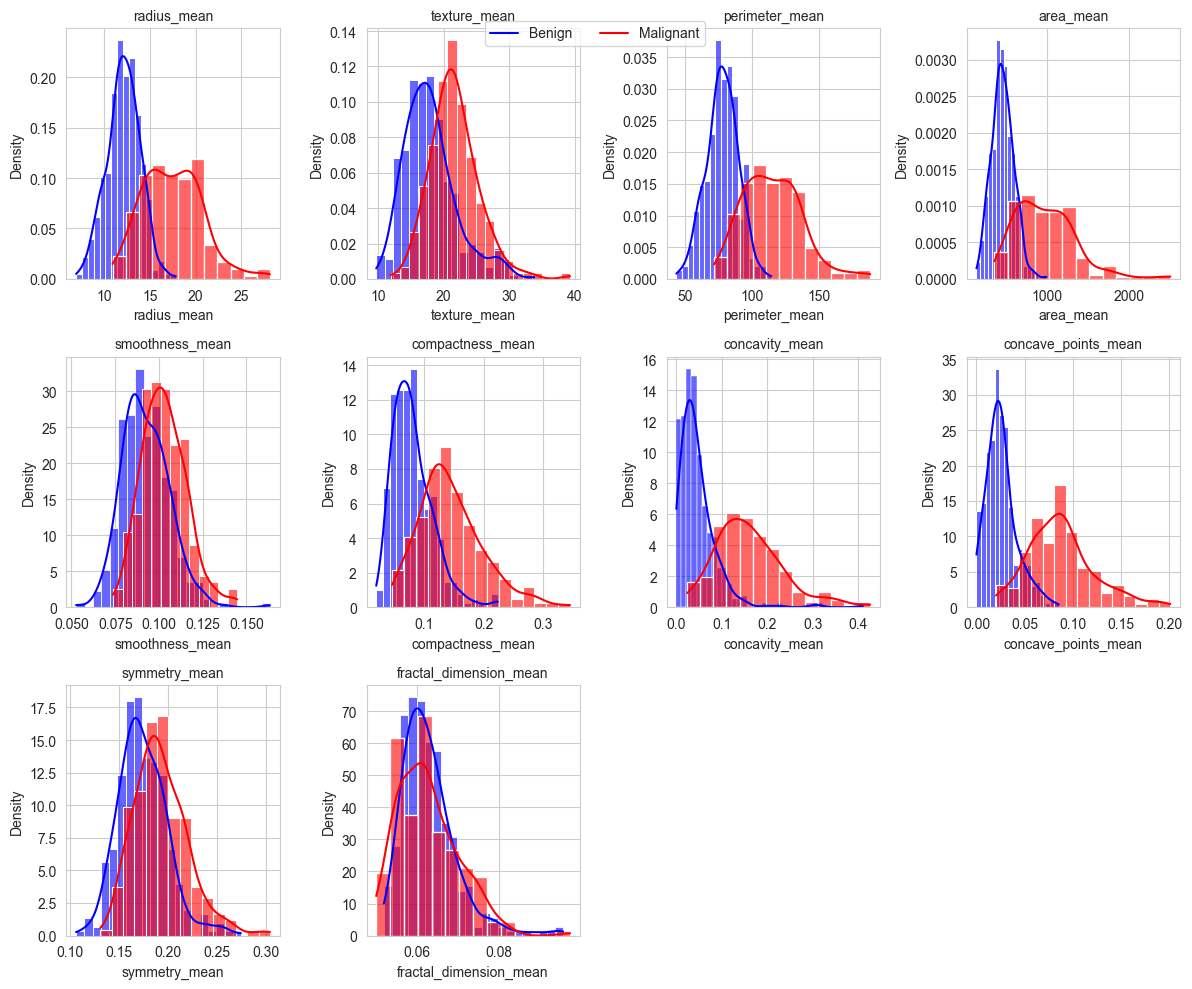

In [285]:
fig = plt.figure(figsize=(12, 10))

# Loop through features to compare distributions
for i, feature in enumerate(list(df.columns[2:12])):  # Adjust the range to your numeric feature columns
    # Enumerate starts at index 0, need to add 1 for subplotting
    i += 1
    
    # Create axes object for position i
    ax = fig.add_subplot(3, 4, i)
    
    # Plot histograms for Benign and Malignant distributions
    sns.histplot(df_benign[feature], kde=True, label='Benign', color='blue', ax=ax, stat="density", alpha=0.6)
    sns.histplot(df_malignant[feature], kde=True, label='Malignant', color='red', ax=ax, stat="density", alpha=0.6)
    # Set the title for the subplot
    ax.set_title(feature, fontsize=10)

# Apply Seaborn style and layout adjustments
sns.set_style("whitegrid")
plt.tight_layout()

# Add a global legend
fig.legend(['Benign', 'Malignant'], loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=2, fontsize=10)

# Show the plot
plt.show()

Clean and Prepare the Data

In [286]:
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True, errors='ignore')
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [287]:
df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [288]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [289]:
import pandas as pd
import numpy as np

# Outlier handling function
def handle_outliers(df, columns, method="cap"):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        if method == "remove":
            df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
        elif method == "cap":
            df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
            df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df


In [290]:
df.corr()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.729376,0.422146,0.741887,0.708389,0.356276,0.595587,0.695648,0.776369,0.327336,...,0.775725,0.461443,0.782470,0.732925,0.419731,0.589453,0.658348,0.793181,0.413382,0.320983
radius_mean,0.729376,1.000000,0.329383,0.997876,0.987344,0.168094,0.505129,0.676557,0.823165,0.144236,...,0.969964,0.300440,0.966231,0.941537,0.117392,0.411329,0.525454,0.744025,0.159877,0.003339
texture_mean,0.422146,0.329383,1.000000,0.335918,0.326193,-0.017769,0.252038,0.315248,0.305590,0.080146,...,0.361964,0.912020,0.369573,0.353434,0.082714,0.290229,0.311122,0.306278,0.116263,0.127177
perimeter_mean,0.741887,0.997876,0.335918,1.000000,0.986548,0.204505,0.555676,0.715662,0.851338,0.179100,...,0.969675,0.307013,0.971157,0.941735,0.148059,0.453304,0.562165,0.770783,0.184458,0.046909
area_mean,0.708389,0.987344,0.326193,0.986548,1.000000,0.174838,0.497981,0.686232,0.824246,0.148219,...,0.963319,0.290565,0.960440,0.959952,0.121543,0.388554,0.511392,0.722009,0.139856,0.000382
smoothness_mean,0.356276,0.168094,-0.017769,0.204505,0.174838,1.000000,0.657741,0.519002,0.551009,0.555259,...,0.209018,0.039977,0.234093,0.202344,0.804667,0.469090,0.431727,0.500119,0.390161,0.496684
compactness_mean,0.595587,0.505129,0.252038,0.555676,0.497981,0.657741,1.000000,0.881619,0.829050,0.598095,...,0.531125,0.258877,0.585188,0.504612,0.564204,0.864097,0.815021,0.813810,0.502439,0.684961
concavity_mean,0.695648,0.676557,0.315248,0.715662,0.686232,0.519002,0.881619,1.000000,0.920462,0.495525,...,0.685826,0.308645,0.726703,0.673187,0.446155,0.751937,0.883184,0.859918,0.401782,0.510736
concave_points_mean,0.776369,0.823165,0.305590,0.851338,0.824246,0.551009,0.829050,0.920462,1.000000,0.457171,...,0.829188,0.301004,0.854468,0.808120,0.450145,0.663532,0.750169,0.909272,0.368009,0.363277
symmetry_mean,0.327336,0.144236,0.080146,0.179100,0.148219,0.555259,0.598095,0.495525,0.457171,1.000000,...,0.179703,0.096533,0.212084,0.170721,0.424045,0.467830,0.429023,0.425146,0.696745,0.434165


<Axes: >

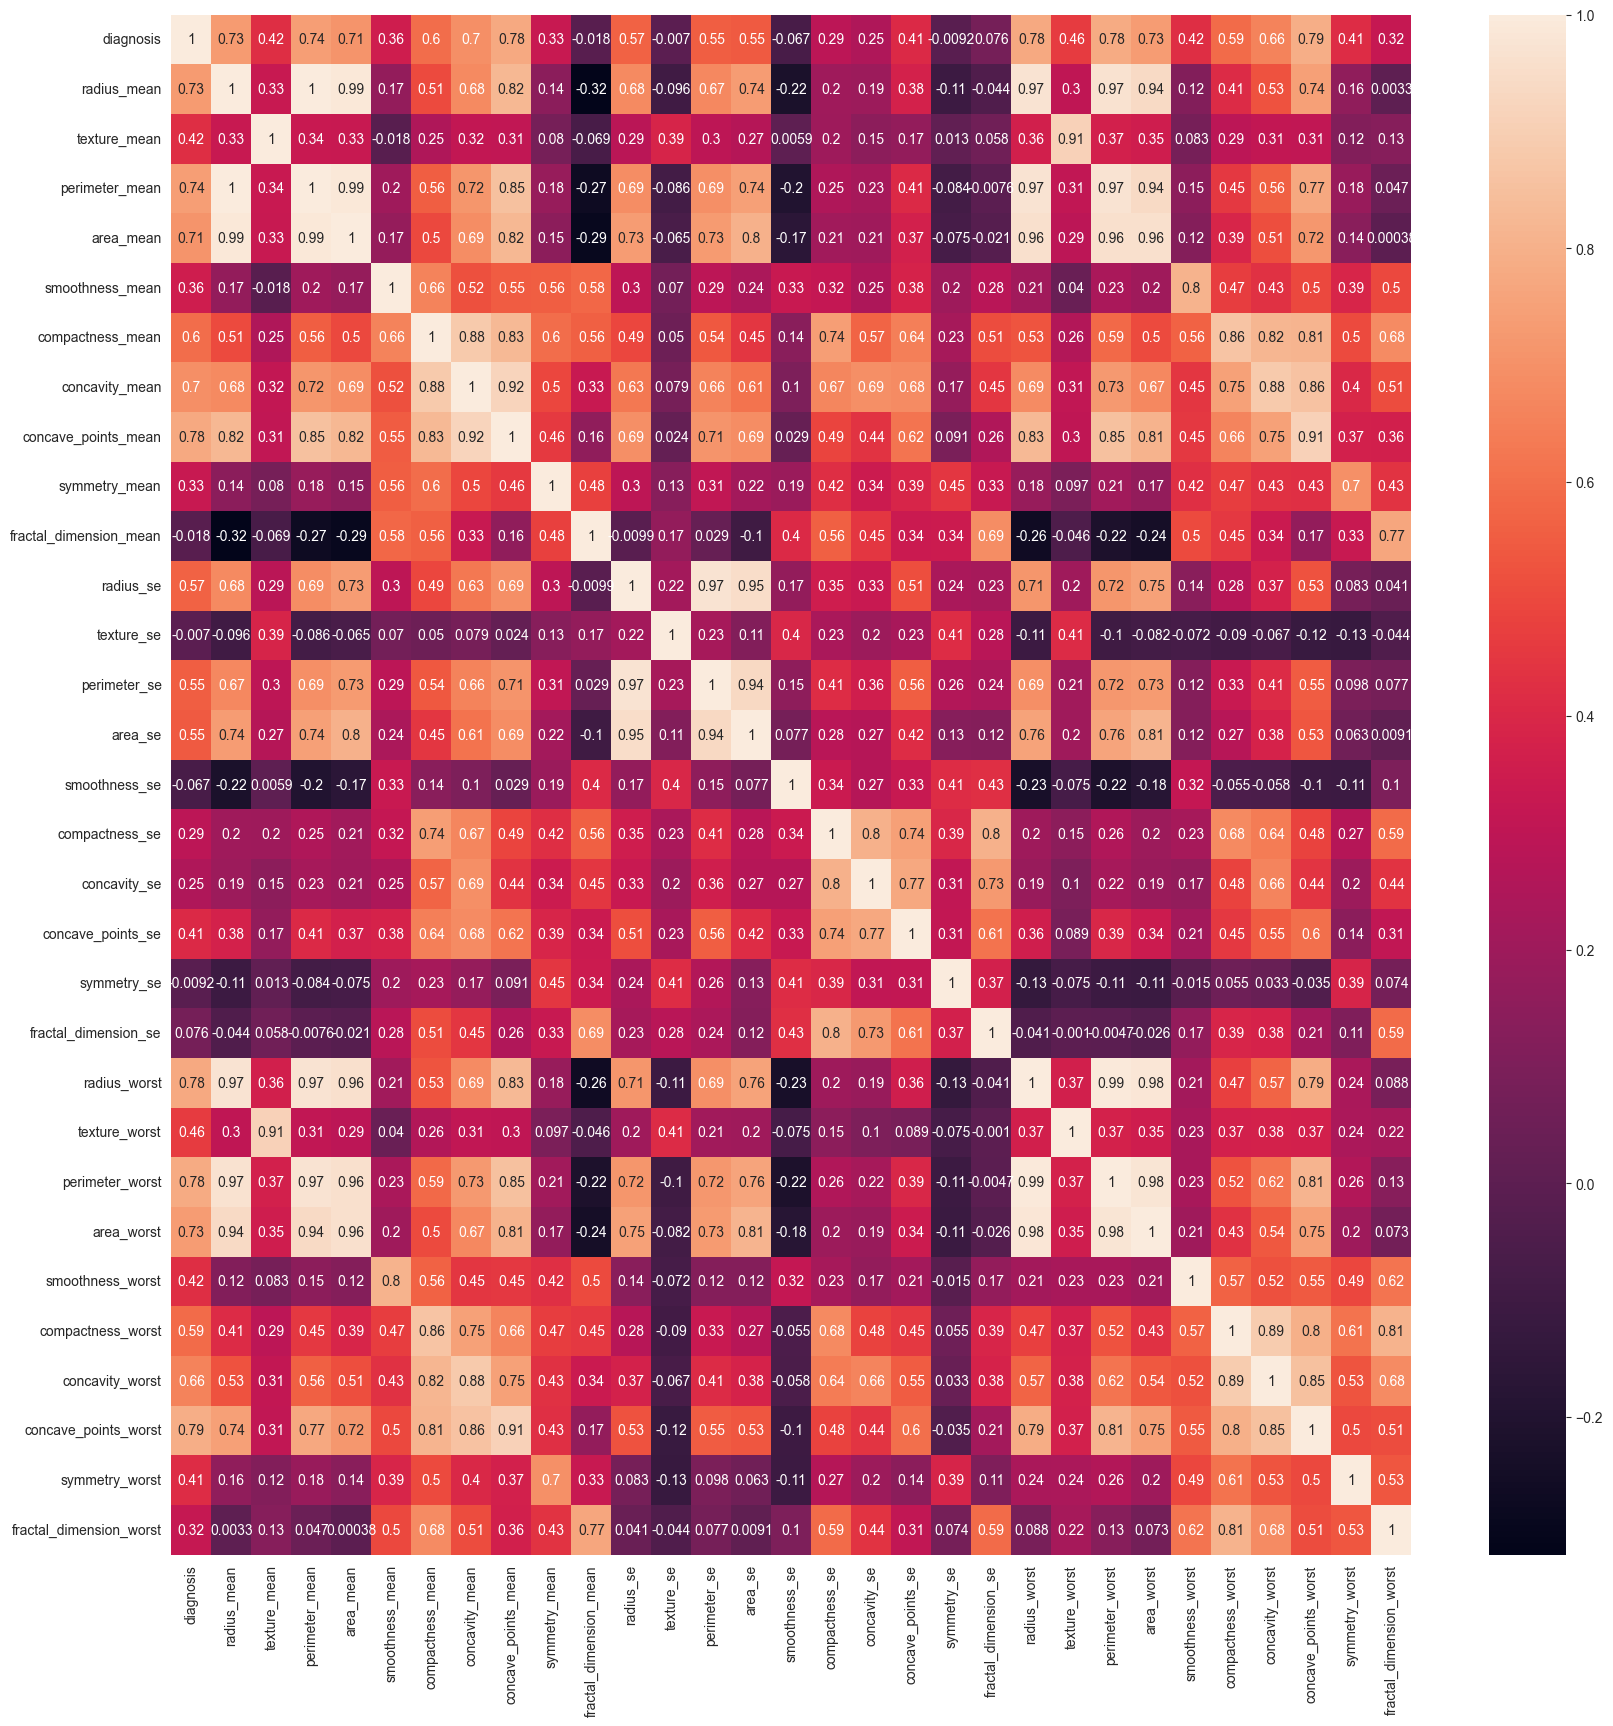

In [291]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=True)


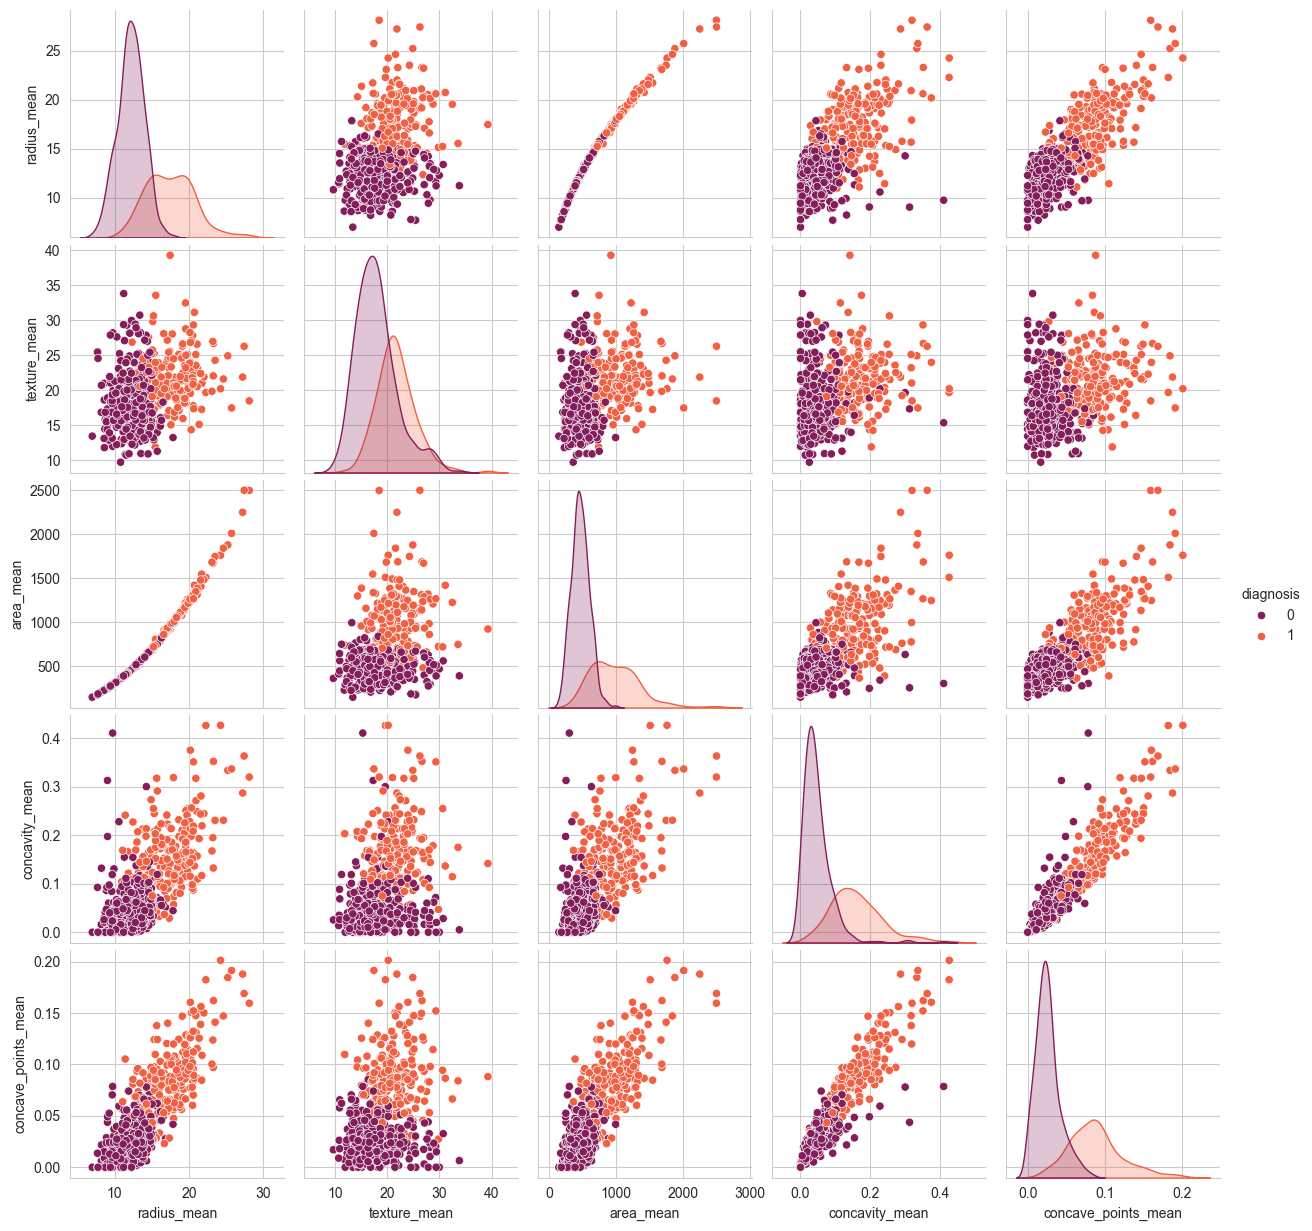

In [292]:
cols = [
    'diagnosis',
    'radius_mean',
    'texture_mean',
    'area_mean',
    'concavity_mean',
    'concave_points_mean'
]

sns.pairplot(df[cols], hue='diagnosis', palette='rocket')


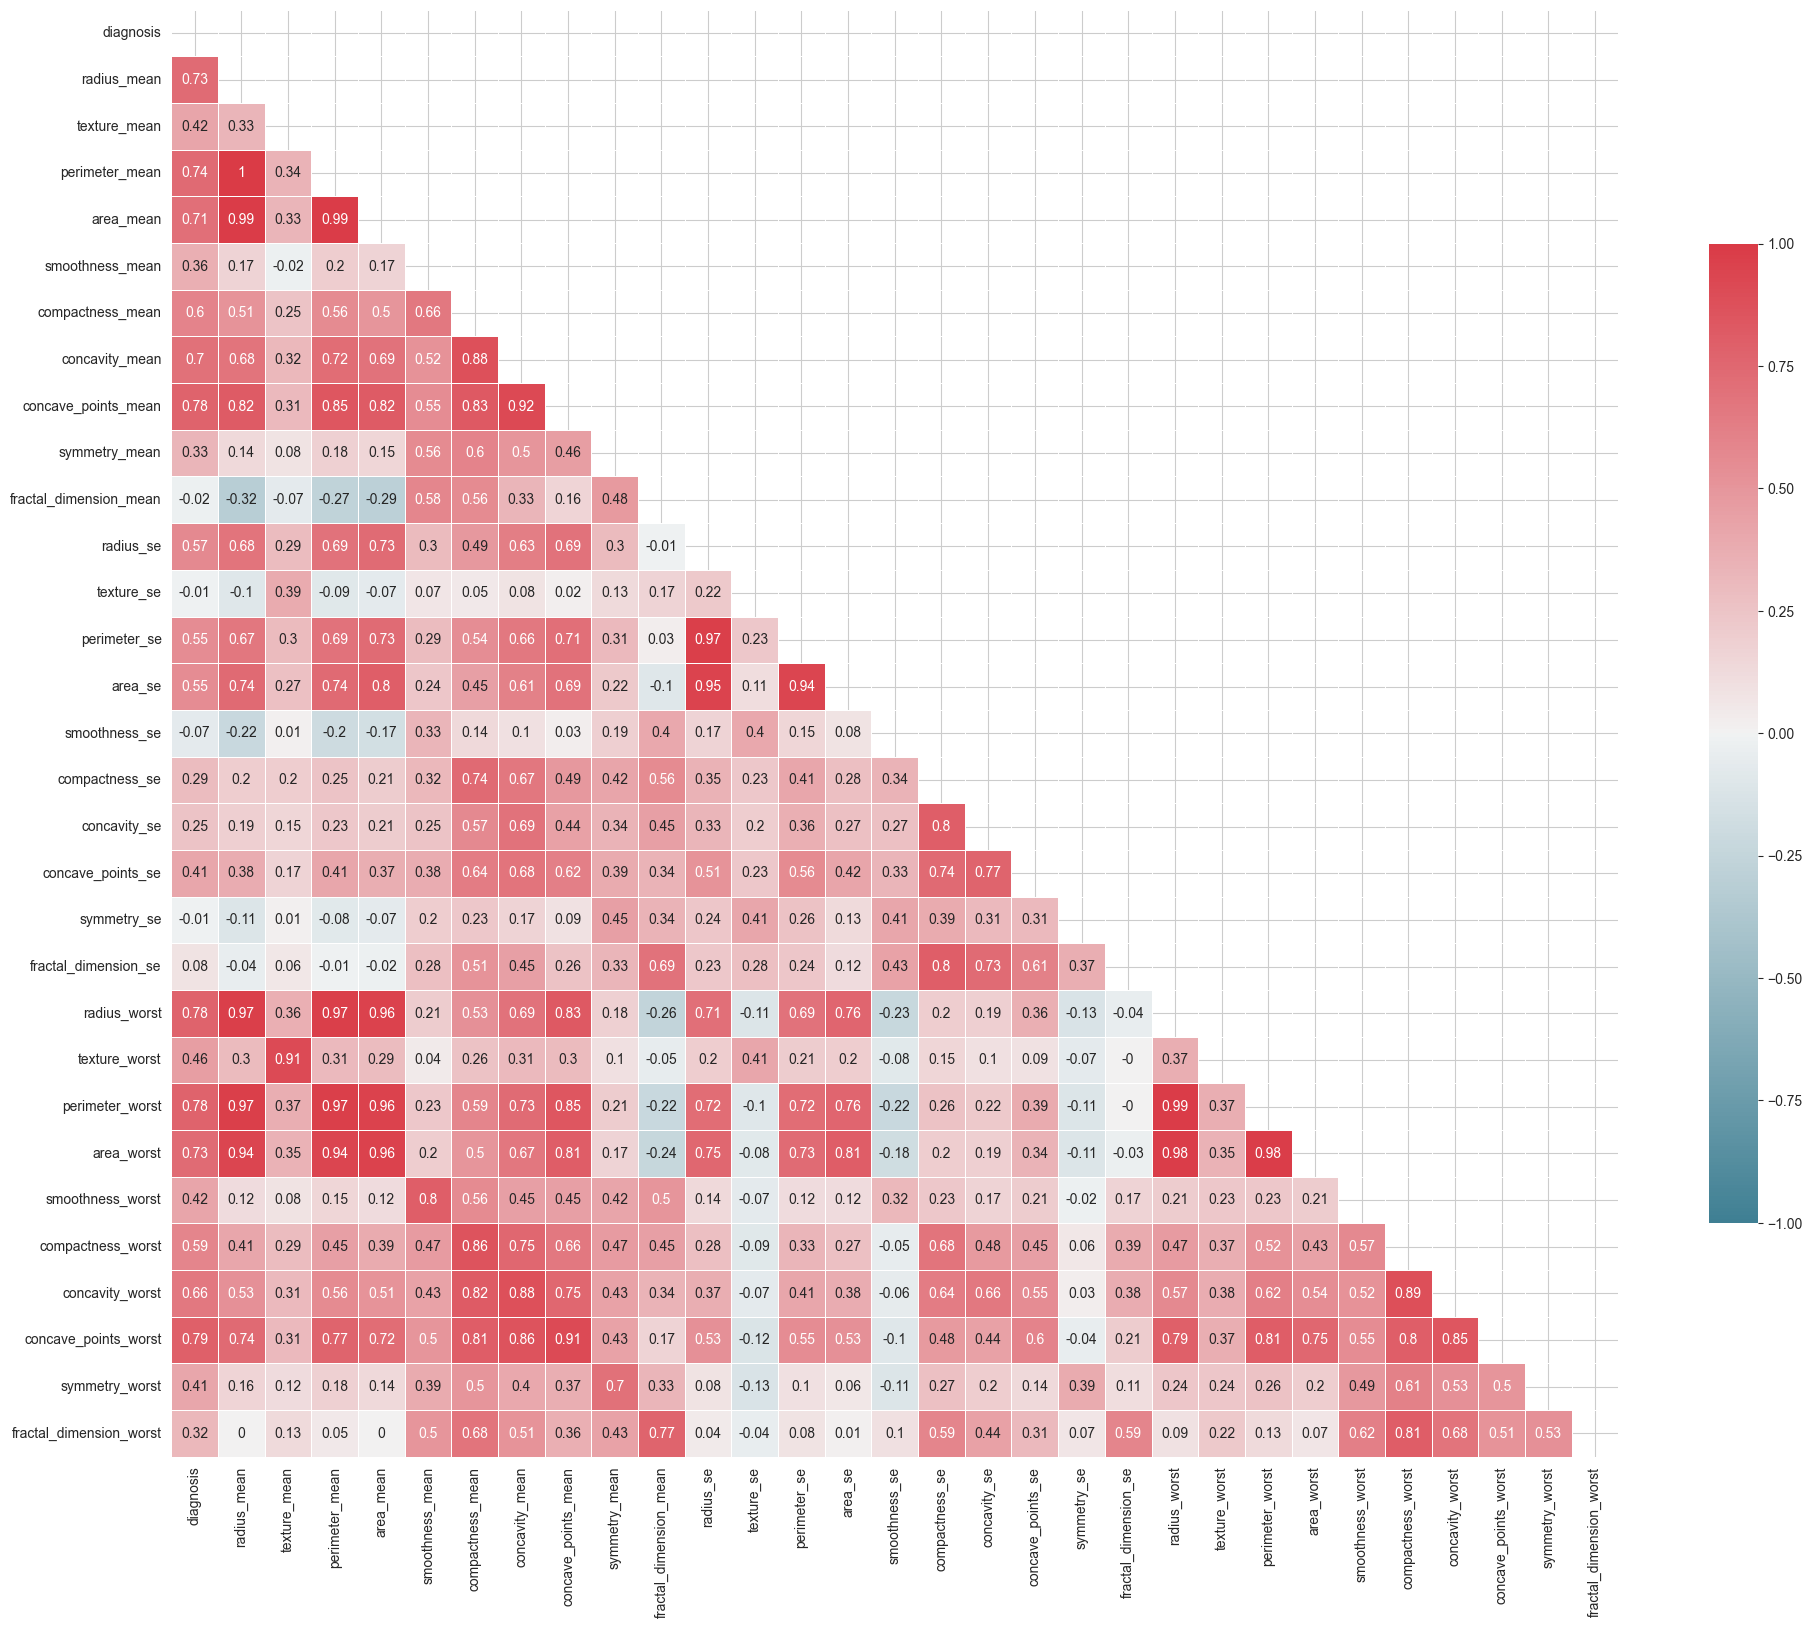

In [293]:
corr = df.corr().round(2)

# Mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)  # Updated `dtype=bool` (instead of `np.bool` which is deprecated)
mask[np.triu_indices_from(mask)] = True

# Set figure size
f, ax = plt.subplots(figsize=(20, 20))

# Define custom colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap
sns.heatmap(
    corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
    square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True
)

plt.tight_layout()
plt.show()


In [294]:
# Define columns to drop
cols_to_drop = [
    # Worst attributes
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst',
    # Perimeter and area attributes
    'perimeter_mean', 'perimeter_se', 'area_mean', 'area_se',
    # Concavity and concave points attributes
    'concavity_mean', 'concavity_se', 'concave_points_mean', 'concave_points_se'
]

# Drop columns, ignoring any that don't exist
df = df.drop(cols_to_drop, axis=1, errors='ignore')

# Verify remaining columns
print(df.columns)


Index(['diagnosis', 'radius_mean', 'texture_mean', 'smoothness_mean',
       'compactness_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'smoothness_se', 'compactness_se',
       'symmetry_se', 'fractal_dimension_se'],
      dtype='object')


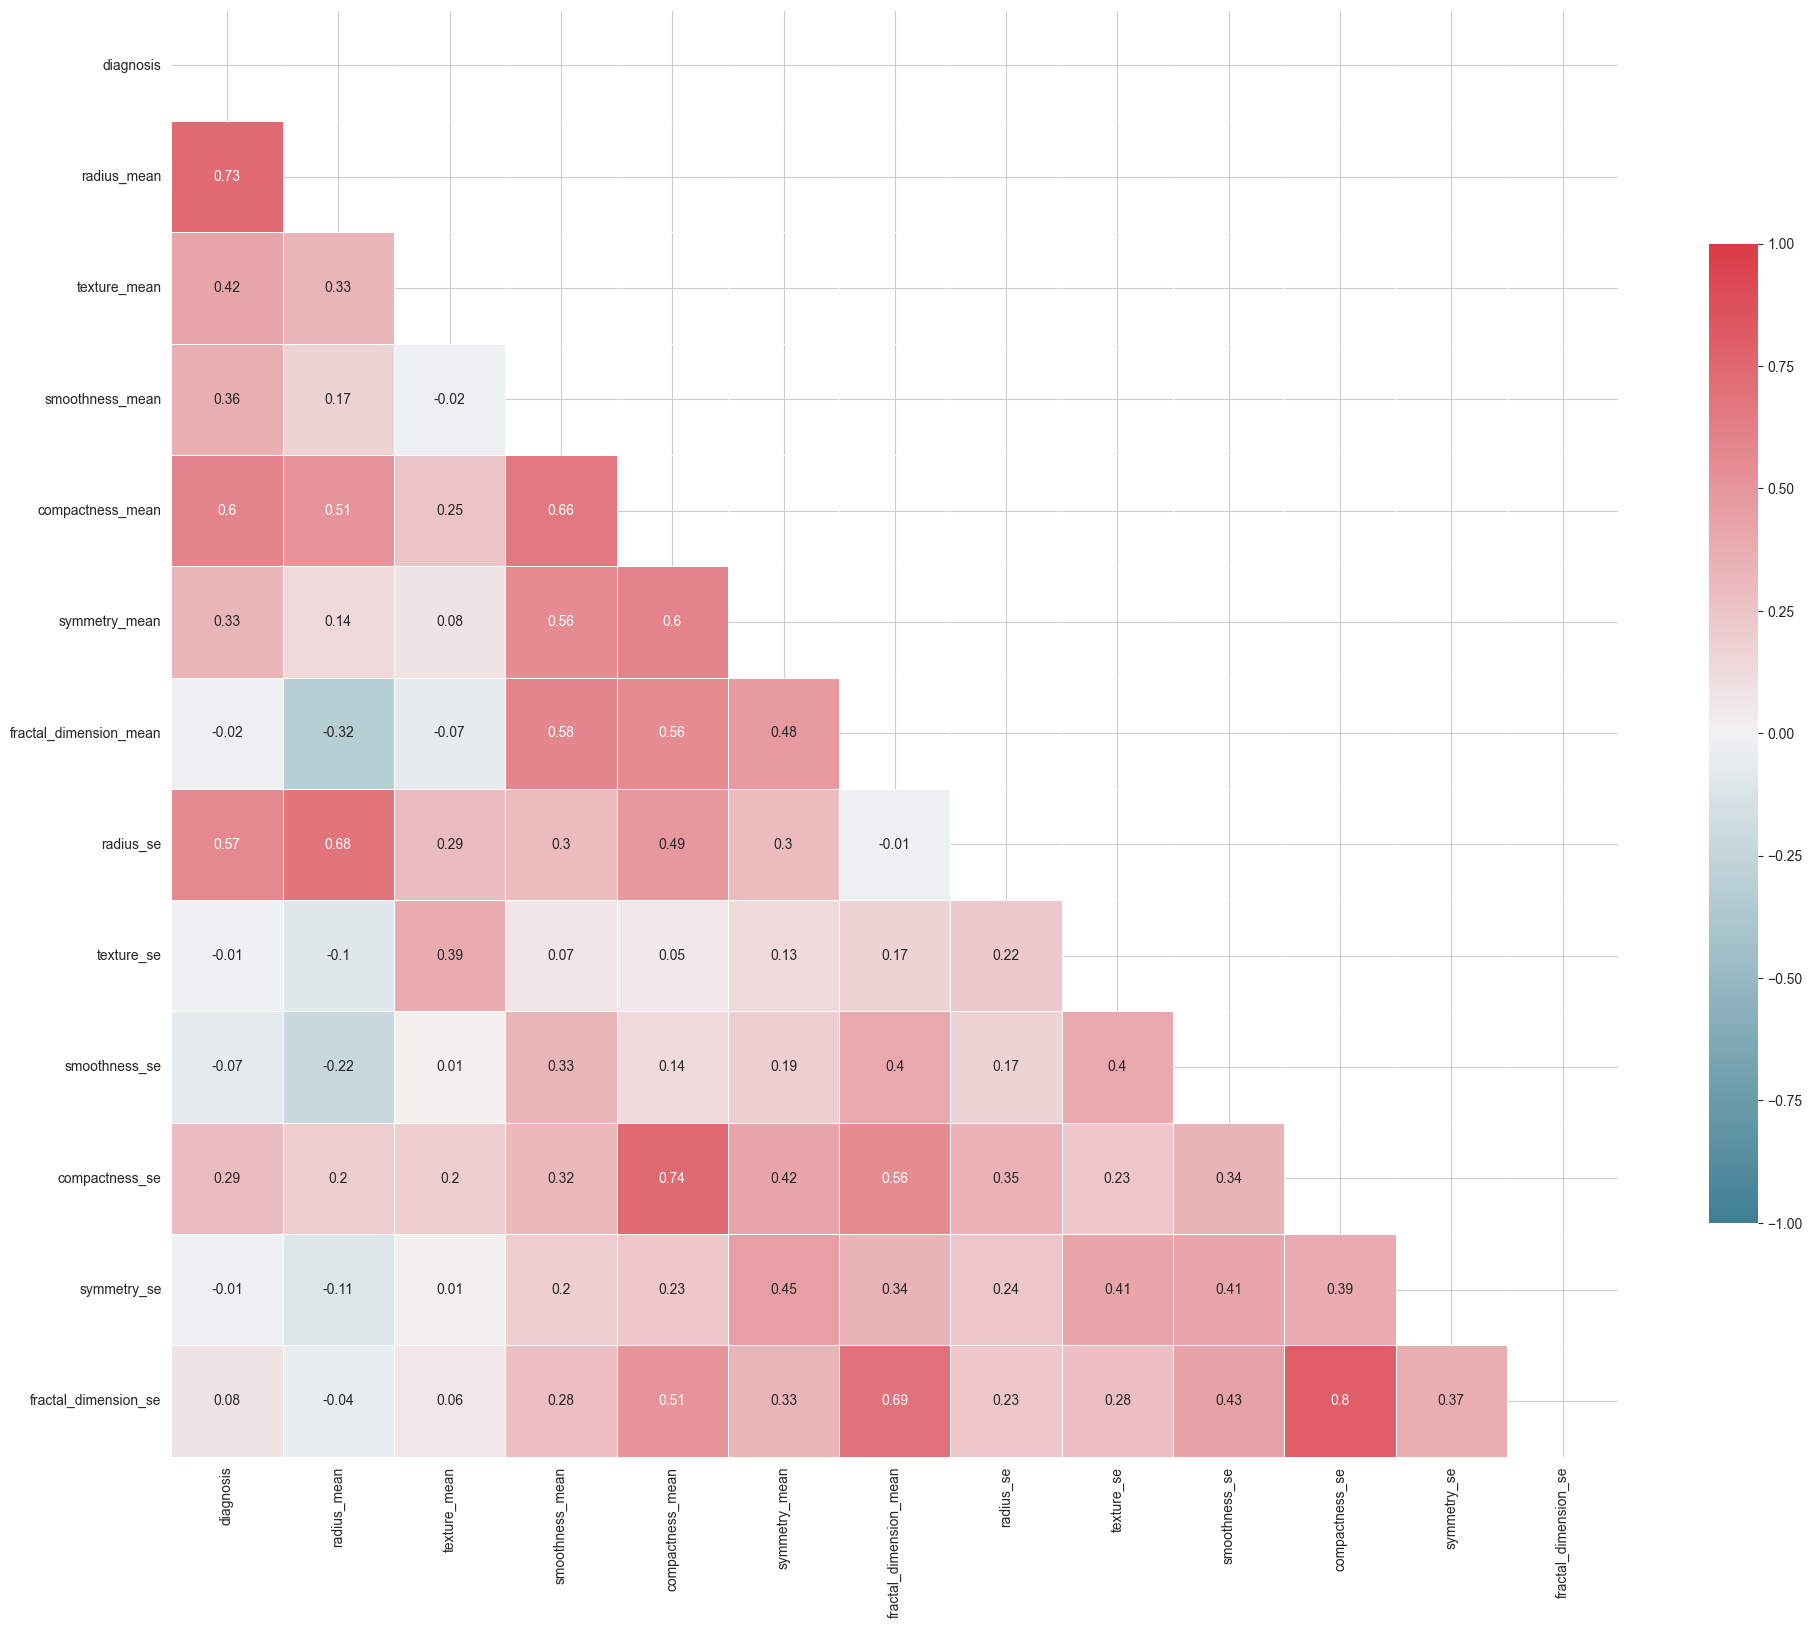

In [295]:
# Compute the new correlation matrix
corr = df.corr().round(2)

# Mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)  # Use dtype=bool instead of np.bool
mask[np.triu_indices_from(mask)] = True

# Set figure size
f, ax = plt.subplots(figsize=(20, 20))

# Define a diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap
sns.heatmap(
    corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
    square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True
)

# Adjust layout for better visualization
plt.tight_layout()

# Display the heatmap
plt.show()


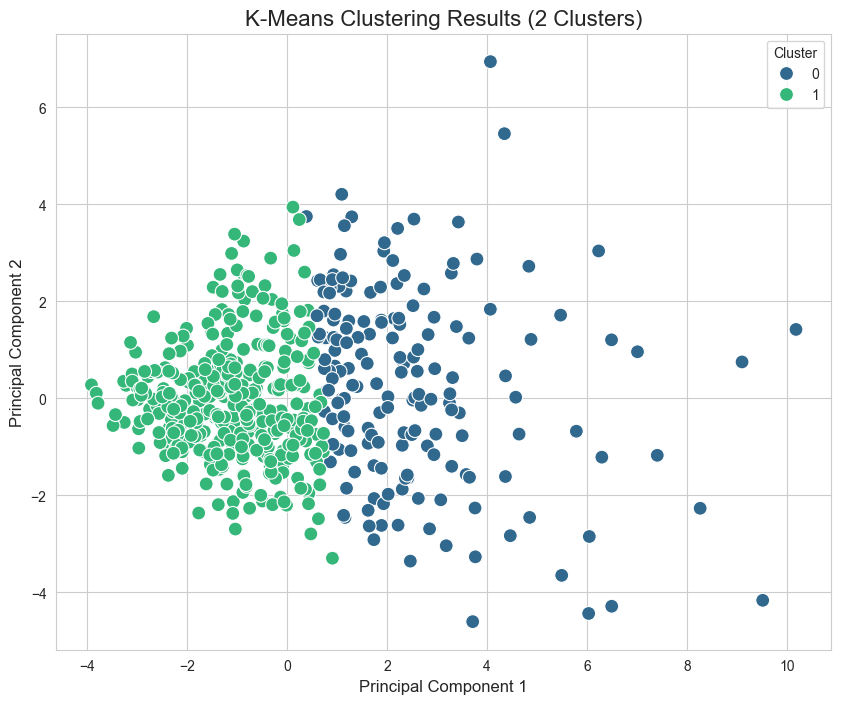

K-Means Inertia: 5210.409450462186


In [296]:

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Assuming df is already loaded
# Dropping the diagnosis column for unsupervised clustering
X = df.drop(columns=['diagnosis'])

# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Performing PCA for dimensionality reduction (optional, to visualize in 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Performing K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Adding cluster labels to the PCA-reduced data
df_clustered = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_clustered['Cluster'] = clusters

# Visualizing the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_clustered, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=100)
plt.title('K-Means Clustering Results (2 Clusters)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster', fontsize=10)
plt.grid(True)
plt.show()

# Evaluating the clustering using inertia (optional)
print(f'K-Means Inertia: {kmeans.inertia_}')


Train-Test Split

In [297]:
X=df.drop(['diagnosis'],axis=1)
y = df['diagnosis']

In [298]:
from sklearn.model_selection import train_test_split

In [299]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=40)

Feature Scaling

In [300]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()

X_train=ss.fit_transform(X_train)
X_test=ss.fit_transform(X_test)

Models and finding out the Best one
Logistic Regression

In [301]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

model1=lr.fit(X_train,y_train)
prediction1=model1.predict(X_test)

In [302]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,prediction1)
cm

array([[104,   3],
       [  4,  60]])

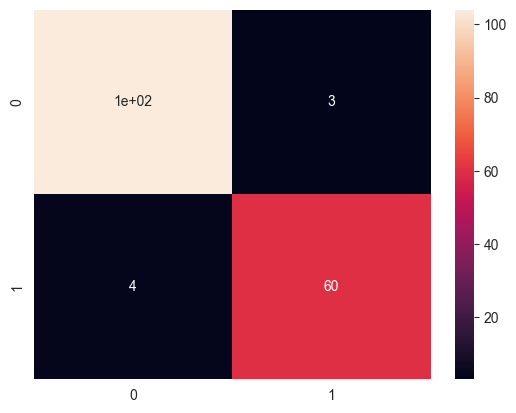

In [303]:
sns.heatmap(cm,annot=True)
plt.savefig('h.png')

In [304]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,prediction1)

0.9590643274853801

Decision Tree

In [305]:
from sklearn.tree import DecisionTreeClassifier

dtc=DecisionTreeClassifier()
model2=dtc.fit(X_train,y_train)
prediction2=model2.predict(X_test)
cm2= confusion_matrix(y_test,prediction2)
cm2

array([[98,  9],
       [13, 51]])

In [306]:
accuracy_score(y_test,prediction2)

0.8713450292397661

Random Forest

In [307]:
from sklearn.ensemble import RandomForestClassifier

rfc=RandomForestClassifier()
model3 = rfc.fit(X_train, y_train)
prediction3 = model3.predict(X_test)
confusion_matrix(y_test, prediction3)

array([[103,   4],
       [  5,  59]])

In [308]:
accuracy_score(y_test, prediction3)

0.9473684210526315

In [309]:
from sklearn.metrics import classification_report
print(classification_report(y_test, prediction3))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       107
           1       0.94      0.92      0.93        64

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



KNN  
Support Vector Machine
Naive Beyes

In [310]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [311]:
models=[]

models.append(('KNN', KNeighborsClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

In [312]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [313]:


# Evaluate each model
results = []
names = []

for name, model in models:
    # Set up k-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=40)  # Use shuffle=True for reproducibility
    # Perform cross-validation
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    # Append results
    results.append(cv_results)
    names.append(name)
    
    # Display results
    msg = '%s: %f (%f)' % (name, cv_results.mean(), cv_results.std())
    print(msg)


KNN: 0.917115 (0.027168)
NB: 0.906923 (0.027264)
SVM: 0.911987 (0.042674)


In [314]:
# make predictions on validation datasets

SVM = SVC()
SVM.fit(X_train, y_train)
predictions= SVM.predict(X_test)
print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

0.9473684210526315
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       107
           1       0.97      0.89      0.93        64

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171

[[105   2]
 [  7  57]]


In [315]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)


ROC Curve Analysis

In [316]:
from sklearn.svm import SVC

svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


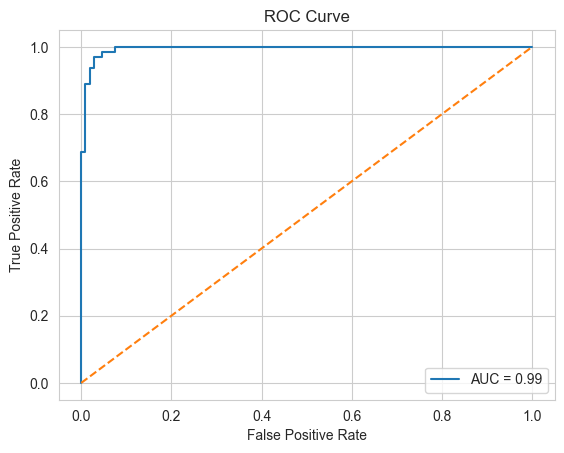

In [317]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = svm_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Feature Importance

In [318]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.1,1,10],
    'kernel':['linear','rbf'],
    'gamma':['scale','auto']
}

grid = GridSearchCV(SVC(probability=True), param_grid, cv=5)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)



Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [319]:
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test)

In [320]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

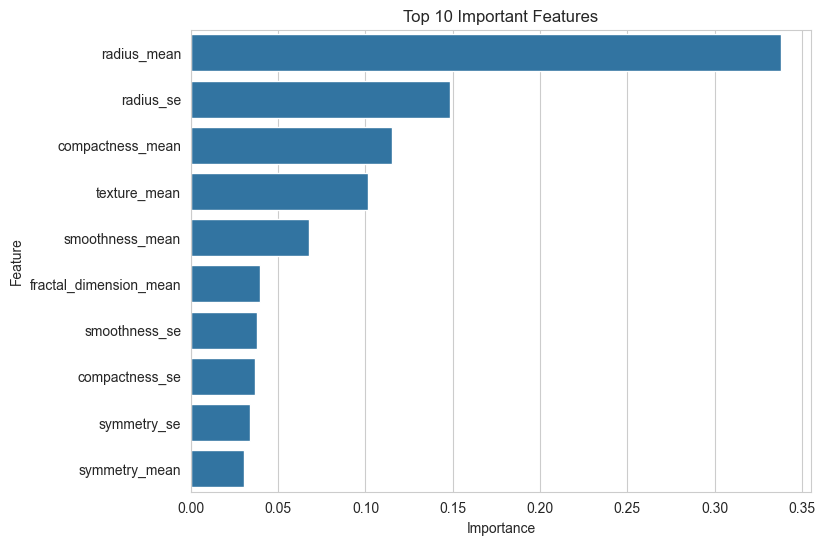

In [321]:
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))

plt.title("Top 10 Important Features")
plt.show()


In [322]:
plt.savefig("../images/feature_importance.png")


<Figure size 640x480 with 0 Axes>

Model Explainability

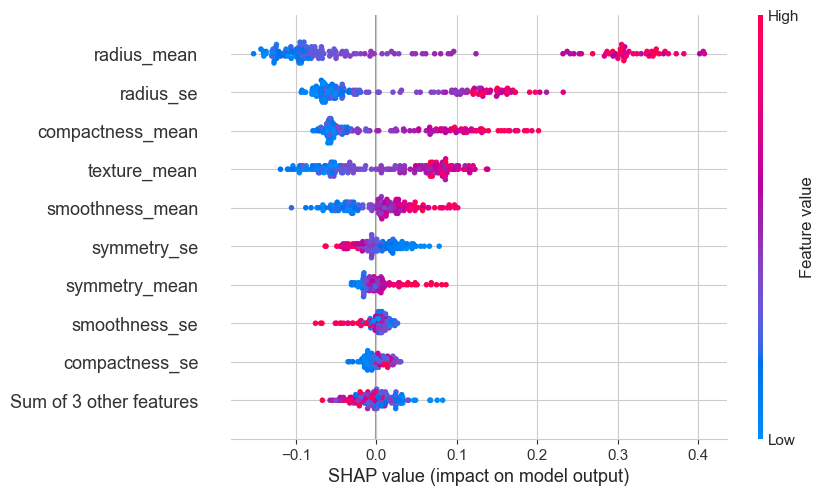

In [323]:
import shap

# Convert to DataFrame so feature names appear
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Create explainer
explainer = shap.Explainer(rf_model, X_test_df)

# Compute SHAP values
shap_values = explainer(X_test_df)

# Select the SHAP values for the malignant class (class 1)
shap.plots.beeswarm(shap_values[:, :, 1])




In [324]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression


In [325]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)



In [326]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)


Logistic Regression Accuracy: 0.9590643274853801


In [327]:
lr_model = LogisticRegression(max_iter=1000)
svm_model = SVC(probability=True)
rf_model = RandomForestClassifier(random_state=42)
knn_model = KNeighborsClassifier()
dt_model = DecisionTreeClassifier()
nb_model = GaussianNB()

lr_model.fit(X_train,y_train)
svm_model.fit(X_train,y_train)
rf_model.fit(X_train,y_train)
knn_model.fit(X_train,y_train)
dt_model.fit(X_train,y_train)
nb_model.fit(X_train,y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [328]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, lr_model.predict(X_test))
svm_acc = accuracy_score(y_test, svm_model.predict(X_test))
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))
knn_acc = accuracy_score(y_test, knn_model.predict(X_test))
dt_acc = accuracy_score(y_test, dt_model.predict(X_test))
nb_acc = accuracy_score(y_test, nb_model.predict(X_test))


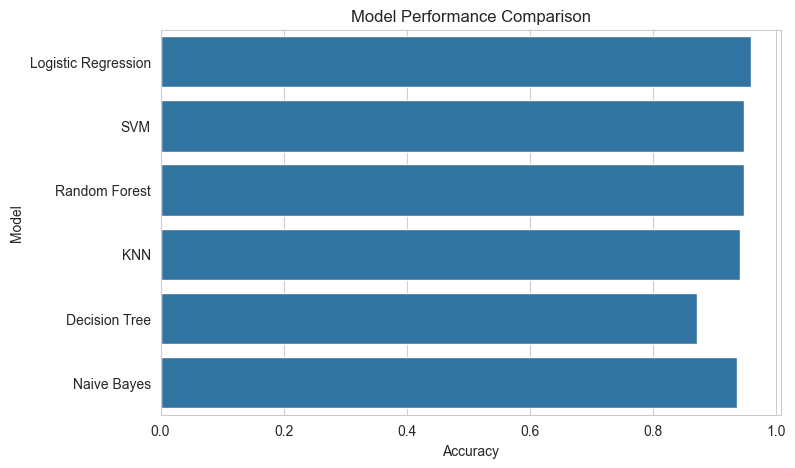

In [329]:
results = {
"Logistic Regression": lr_acc,
"SVM": svm_acc,
"Random Forest": rf_acc,
"KNN": knn_acc,
"Decision Tree": dt_acc,
"Naive Bayes": nb_acc
}

results_df = pd.DataFrame(results.items(), columns=["Model","Accuracy"])

plt.figure(figsize=(8,5))
sns.barplot(x="Accuracy",y="Model",data=results_df)
plt.title("Model Performance Comparison")
plt.show()


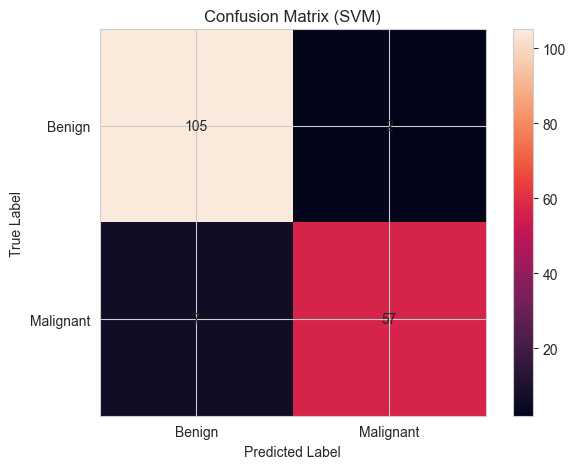

In [330]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, predictions)

# Class labels
classes = ['Benign', 'Malignant']

# Plot
plt.figure()
plt.imshow(cm)
plt.title('Confusion Matrix (SVM)')
plt.colorbar()

# Tick marks
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Add numbers inside the boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center')

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()



Conclusion
The results demonstrate that machine learning models can effectively classify breast cancer tumors using diagnostic measurements. Support Vector Machines achieved the highest accuracy, while feature importance analysis revealed that tumor size and shape characteristics are the most predictive features.